# Clean Up a Phone GPS Track in Five Lines

This drive is from the Google Smartphone Decimeter Challenge public dataset. To fetch the source data yourself:

```bash
kaggle competitions download -c google-smartphone-decimeter-challenge -p /tmp/gsdc
unzip /tmp/gsdc/google-smartphone-decimeter-challenge.zip -d /tmp/gsdc
```

This notebook reads the local copy through `DATA_DIR`. The GSDC data is CC BY and is not stored in this repo. The broadcast navigation file is also read from a local path when present, otherwise it is fetched into the Sidereon cache.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sidereon
from sidereon import data

plt.rcParams.update({"figure.dpi": 140, "axes.grid": True, "grid.alpha": 0.25})

DATA_DIR = Path("/private/tmp/fusion-trial/data/gsdc/2020-05-14-US-MTV-1")
RINEX_PATH = DATA_DIR / "Pixel4_GnssLog.20o"
TRUTH_PATH = DATA_DIR / "SPAN_Pixel4_10Hz.nmea"
LOCAL_NAV_PATH = Path("/private/tmp/fusion-trial/data/BRDM00DLR_S_20201350000_01D_MN.rnx")
DRIVE_DATE = (2020, 5, 14)

missing = [path for path in (RINEX_PATH, TRUTH_PATH) if not path.exists()]
READY = not missing
if READY:
    print(f"Using phone data in {DATA_DIR}")
else:
    print("Data files were not found. Set DATA_DIR to the unpacked GSDC drive folder and rerun.")
    for path in missing:
        print(f"Missing: {path}")

Using phone data in /private/tmp/fusion-trial/data/gsdc/2020-05-14-US-MTV-1


## Load the phone observations and truth

The RINEX file in this copy ends with an incomplete final epoch. The loader drops only that trailing record in memory, then parses the original file content.

In [2]:
def parse_phone_rinex(path):
    text = path.read_text()
    try:
        return sidereon.parse_rinex_obs(text), "parsed as-is"
    except sidereon.RinexObsParseError as first_error:
        lines = text.splitlines()
        epoch_starts = [i for i, line in enumerate(lines) if line.startswith(">")]
        if not epoch_starts:
            raise first_error
        start = epoch_starts[-1]
        expected = int(lines[start].split()[8])
        present = sum(1 for line in lines[start + 1 :] if line.strip())
        if present >= expected:
            raise first_error
        trimmed = "\n".join(lines[:start]) + "\n"
        note = f"dropped trailing incomplete epoch: expected {expected}, found {present}"
        return sidereon.parse_rinex_obs(trimmed), note


def load_navigation_product():
    if LOCAL_NAV_PATH.exists():
        print(f"Using local broadcast navigation: {LOCAL_NAV_PATH}")
        return sidereon.load_rinex_nav(LOCAL_NAV_PATH)
    year, month, day = DRIVE_DATE
    product = data.product("igs", "nav", __import__("datetime").date(year, month, day))
    path = data.fetch(product)
    print(f"Fetched broadcast navigation into cache: {path}")
    return sidereon.load_rinex_nav(path)


def ecef_from_geodetic_deg_m(geodetic_deg_m):
    geodetic_km = np.asarray(geodetic_deg_m, dtype=np.float64).copy()
    geodetic_km[:, 2] /= 1000.0
    return sidereon.geodetic_to_ecef(geodetic_km) * 1000.0


def geodetic_from_ecef_m(position_m):
    return sidereon.ecef_to_geodetic(np.asarray(position_m, dtype=np.float64) / 1000.0)


def load_truth(path):
    times_s = []
    geodetic_rows = []
    for snapshot in sidereon.parse_nmea(path.read_bytes()).group_epochs():
        if snapshot.time is None or snapshot.position_geodetic is None:
            continue
        hour, minute, second, nanosecond, _precision = snapshot.time
        times_s.append(hour * 3600.0 + minute * 60.0 + second + nanosecond * 1e-9)
        lat_deg, lon_deg, height_m = snapshot.position_geodetic
        geodetic_rows.append([lat_deg, lon_deg, height_m])
    truth_utc_s = np.asarray(times_s, dtype=np.float64)
    truth_ecef_m = ecef_from_geodetic_deg_m(np.asarray(geodetic_rows, dtype=np.float64))
    return truth_utc_s, truth_ecef_m


def interpolate_truth(query_gpst_s, truth_utc_s, truth_ecef_m):
    year, month, day = DRIVE_DATE
    gps_minus_utc_s = sidereon.leap_seconds(year, month, day) - 19.0
    query_utc_s = np.asarray(query_gpst_s, dtype=np.float64) - gps_minus_utc_s
    return np.column_stack(
        [np.interp(query_utc_s, truth_utc_s, truth_ecef_m[:, axis]) for axis in range(3)]
    )

if READY:
    rinex_obs, rinex_note = parse_phone_rinex(RINEX_PATH)
    broadcast_nav = load_navigation_product()
    truth_utc_s, truth_ecef_m = load_truth(TRUTH_PATH)
    print(f"RINEX epochs: {rinex_obs.epoch_count} ({rinex_note})")
    print(f"Truth samples: {len(truth_utc_s)} at 10 Hz")
else:
    print("Skipped loading because DATA_DIR is not set to the local drive folder.")

Using local broadcast navigation: /private/tmp/fusion-trial/data/BRDM00DLR_S_20201350000_01D_MN.rnx


RINEX epochs: 1733 (dropped trailing incomplete epoch: expected 24, found 18)
Truth samples: 23771 at 10 Hz


## Raw SPP fixes

Use C1C pseudoranges from GPS and Galileo. The first seed is only a rough Mountain View coordinate; after that each epoch starts from the previous fix.

In [3]:
def epoch_seconds_of_day(epoch_time):
    return sidereon.second_of_day(epoch_time.hour, epoch_time.minute, epoch_time.second)


def epoch_j2000_seconds(epoch_time):
    return sidereon.j2000_seconds(
        epoch_time.year,
        epoch_time.month,
        epoch_time.day,
        epoch_time.hour,
        epoch_time.minute,
        epoch_time.second,
    )


def epoch_day_of_year(epoch_time):
    return sidereon.day_of_year(
        epoch_time.year,
        epoch_time.month,
        epoch_time.day,
        epoch_time.hour,
        epoch_time.minute,
        epoch_time.second,
    )

if READY:
    signal_filter = sidereon.ObservationFilter(
        [(sidereon.GnssSystem.GPS, ["C1C"]), (sidereon.GnssSystem.GALILEO, ["C1C"])]
    )
    last_position_m = ecef_from_geodetic_deg_m(np.array([[37.42, -122.09, 20.0]]))[0]
    raw_positions, ecef_covariances, enu_covariances = [], [], []
    gpst_s, residual_rms_m, used_counts, skipped = [], [], [], []

    for index in range(rinex_obs.epoch_count):
        epoch = rinex_obs.epochs[index]
        rows = rinex_obs.observation_values(index, signal_filter)
        observations = [
            sidereon.SppObservation(sat, float(value))
            for sat, value in zip(rows.satellites, rows.values)
            if np.isfinite(value) and value > 1e6
        ]
        if len(observations) < 6:
            skipped.append(index)
            continue

        t = epoch.epoch
        config = sidereon.SppConfig(
            observations=observations,
            t_rx_j2000_s=epoch_j2000_seconds(t),
            t_rx_second_of_day_s=epoch_seconds_of_day(t),
            day_of_year=epoch_day_of_year(t),
            initial_guess=[float(last_position_m[0]), float(last_position_m[1]), float(last_position_m[2]), 0.0],
            corrections=sidereon.SppCorrections(ionosphere=False, troposphere=True),
            with_geodetic=True,
        )
        try:
            solution = sidereon.solve_broadcast(broadcast_nav, config)
        except sidereon.SolveError:
            skipped.append(index)
            continue

        raw_positions.append(solution.position.copy())
        ecef_covariances.append(solution.position_covariance_ecef_m2.copy())
        enu_covariances.append(solution.position_covariance_enu_m2.copy())
        gpst_s.append(epoch_seconds_of_day(t))
        used_counts.append(len(solution.used_sats))
        residual_rms_m.append(float(np.sqrt(np.mean(np.asarray(solution.residuals_m) ** 2))))
        last_position_m = solution.position.copy()

    raw_xyz_m = np.asarray(raw_positions)
    ecef_covariances_m2 = np.asarray(ecef_covariances)
    enu_covariances_m2 = np.asarray(enu_covariances)
    gpst_s = np.asarray(gpst_s)
    residual_rms_m = np.asarray(residual_rms_m)
    used_counts = np.asarray(used_counts)
    truth_xyz_m = interpolate_truth(gpst_s, truth_utc_s, truth_ecef_m)
    raw_error_m = np.linalg.norm(raw_xyz_m - truth_xyz_m, axis=1)

    print(f"Solved {len(raw_xyz_m)} of {rinex_obs.epoch_count} epochs; skipped {len(skipped)}.")
    print(f"Used satellites per fix: {used_counts.min()} to {used_counts.max()}.")
else:
    print("Skipped SPP solve because the input files are missing.")

Solved 1731 of 1733 epochs; skipped 2.
Used satellites per fix: 7 to 14.


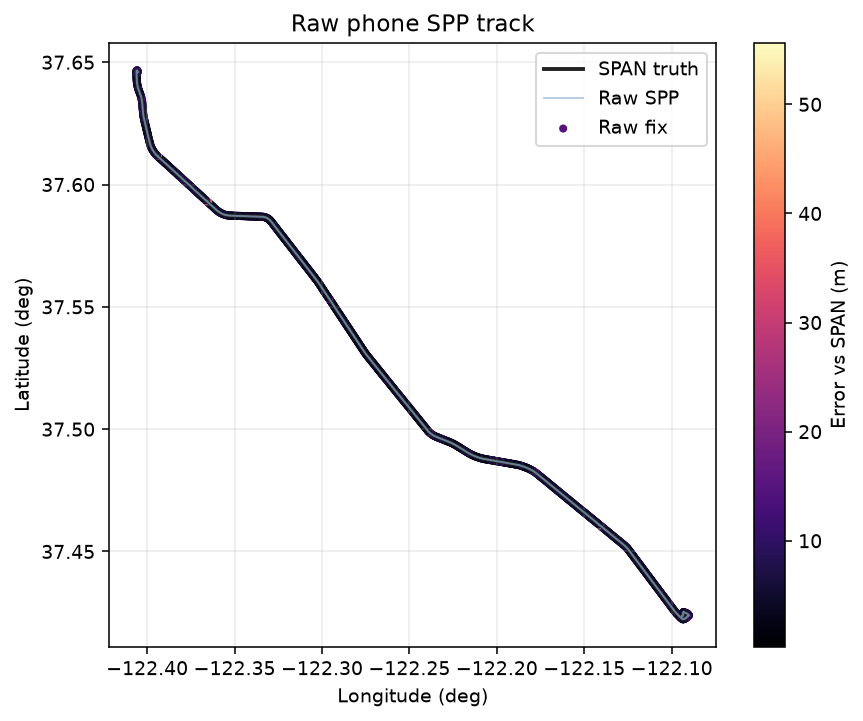

In [4]:
if READY:
    raw_llh = geodetic_from_ecef_m(raw_xyz_m)
    truth_llh = geodetic_from_ecef_m(truth_xyz_m)

    fig, ax = plt.subplots(figsize=(7.0, 5.6))
    ax.plot(truth_llh[:, 1], truth_llh[:, 0], color="#222222", lw=2.0, label="SPAN truth")
    ax.plot(raw_llh[:, 1], raw_llh[:, 0], color="#8fb3d9", lw=1.0, alpha=0.65, label="Raw SPP")
    sc = ax.scatter(raw_llh[:, 1], raw_llh[:, 0], c=raw_error_m, s=10, cmap="magma", label="Raw fix")
    ax.set_title("Raw phone SPP track")
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.legend(loc="best")
    fig.colorbar(sc, ax=ax, label="Error vs SPAN (m)")
    plt.show()
else:
    print("Skipped plot because the input files are missing.")

## Let the fix say how much it should count

SPP gives a geometry covariance. Scale it by that epoch's residual scatter, and a bad fit becomes a wide fix that moves the track less.

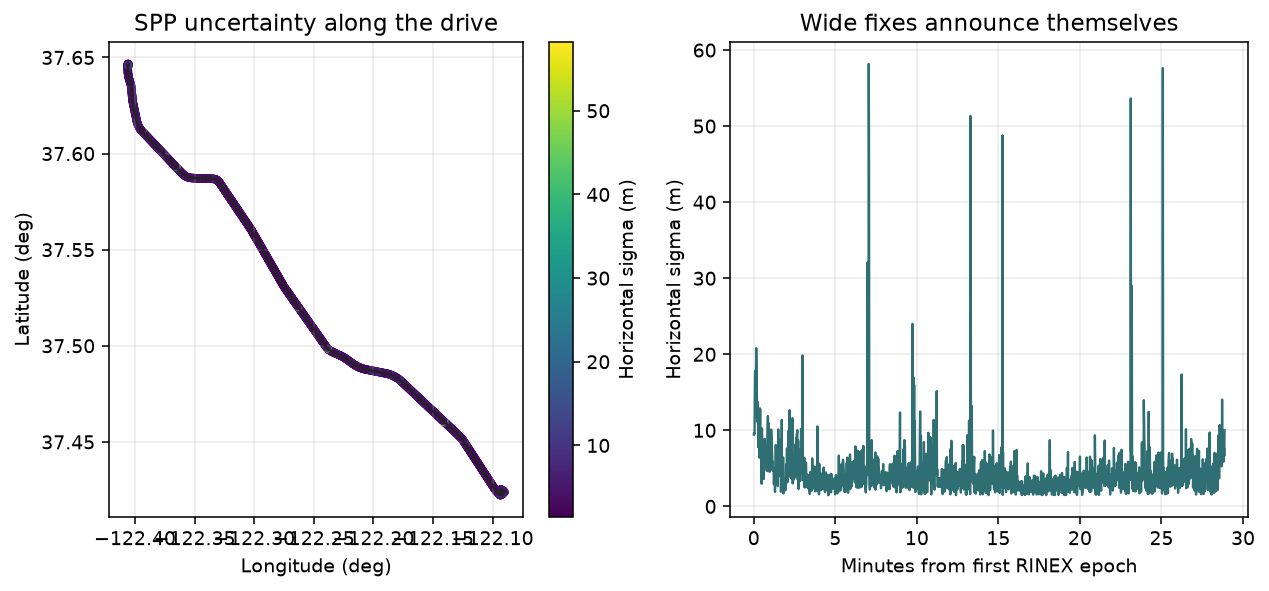

Horizontal sigma: median 3.6 m, p95 9.1 m, max 58.2 m.


In [5]:
if READY:
    residual_floor_m = 1.0
    residual_scale_m = np.maximum(residual_rms_m, residual_floor_m)
    tracker_covariances_m2 = ecef_covariances_m2 * residual_scale_m[:, None, None] ** 2
    tracker_enu_covariances_m2 = enu_covariances_m2 * residual_scale_m[:, None, None] ** 2
    horizontal_sigma_m = np.sqrt(np.trace(tracker_enu_covariances_m2[:, :2, :2], axis1=1, axis2=2))
    elapsed_min = (gpst_s - gpst_s[0]) / 60.0

    fig, (ax_track, ax_sigma) = plt.subplots(1, 2, figsize=(10.5, 4.4))
    sc = ax_track.scatter(raw_llh[:, 1], raw_llh[:, 0], c=horizontal_sigma_m, s=11, cmap="viridis")
    ax_track.plot(truth_llh[:, 1], truth_llh[:, 0], color="#222222", lw=1.4)
    ax_track.set_title("SPP uncertainty along the drive")
    ax_track.set_xlabel("Longitude (deg)")
    ax_track.set_ylabel("Latitude (deg)")
    fig.colorbar(sc, ax=ax_track, label="Horizontal sigma (m)")

    ax_sigma.plot(elapsed_min, horizontal_sigma_m, color="#2f6f73", lw=1.2)
    ax_sigma.set_title("Wide fixes announce themselves")
    ax_sigma.set_xlabel("Minutes from first RINEX epoch")
    ax_sigma.set_ylabel("Horizontal sigma (m)")
    plt.show()

    print(
        "Horizontal sigma: "
        f"median {np.median(horizontal_sigma_m):.1f} m, "
        f"p95 {np.percentile(horizontal_sigma_m, 95):.1f} m, "
        f"max {horizontal_sigma_m.max():.1f} m."
    )
else:
    print("Skipped covariance plot because the input files are missing.")

## TrackFilter in five lines

Feed each fix with its covariance. Wide fixes get low weight, so they stop pulling the path sideways.

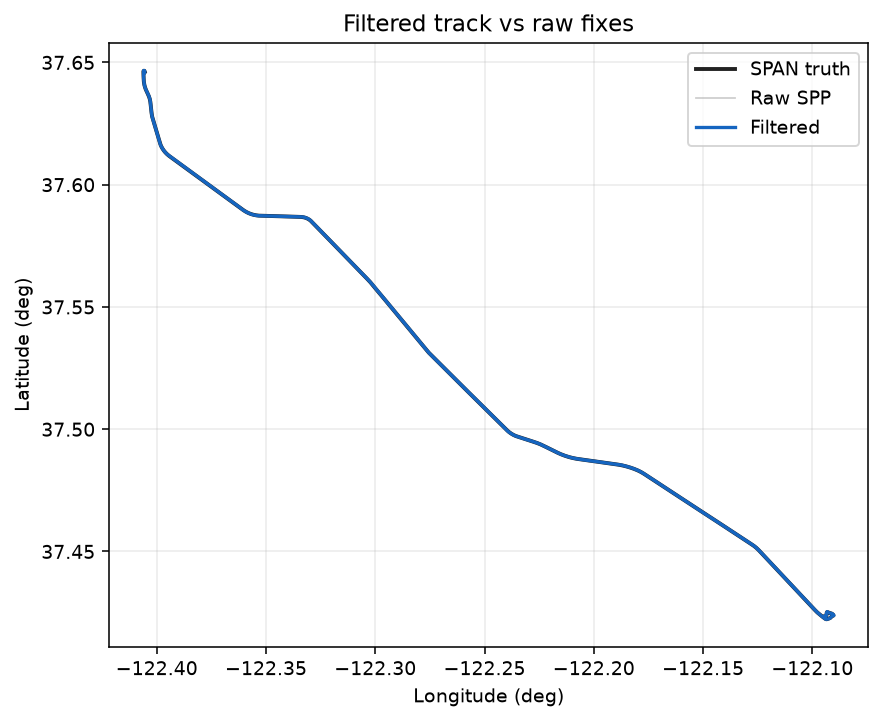

In [6]:
if READY:
    filt = sidereon.TrackFilter.from_position(sidereon.TrackCoordinateFrame.ECEF, float(gpst_s[0]), raw_xyz_m[0], tracker_covariances_m2[0], 1.0, 0.2)
    history = sidereon.TrackRtsHistoryBuilder.from_filter(filt)
    filtered_xyz_m = [raw_xyz_m[0]]
    for t_s, fix_m, cov_m2 in zip(gpst_s[1:], raw_xyz_m[1:], tracker_covariances_m2[1:]):
        filt.predict_recorded(float(t_s - filt.state.t_s), history)
        filtered_xyz_m.append(filt.update_position_recorded(fix_m, cov_m2, history).updated.position_m.copy())
    filtered_xyz_m = np.asarray(filtered_xyz_m)

    filtered_llh = geodetic_from_ecef_m(filtered_xyz_m)
    fig, ax = plt.subplots(figsize=(7.0, 5.6))
    ax.plot(truth_llh[:, 1], truth_llh[:, 0], color="#222222", lw=2.0, label="SPAN truth")
    ax.plot(raw_llh[:, 1], raw_llh[:, 0], color="#b8b8b8", lw=0.9, alpha=0.7, label="Raw SPP")
    ax.plot(filtered_llh[:, 1], filtered_llh[:, 0], color="#1565c0", lw=1.7, label="Filtered")
    ax.set_title("Filtered track vs raw fixes")
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.legend(loc="best")
    plt.show()
else:
    print("Skipped filtering because the input files are missing.")

## Smooth the recorded history

The forward pass has a history buffer. The smoother uses that buffer to clean up points after seeing the whole drive.

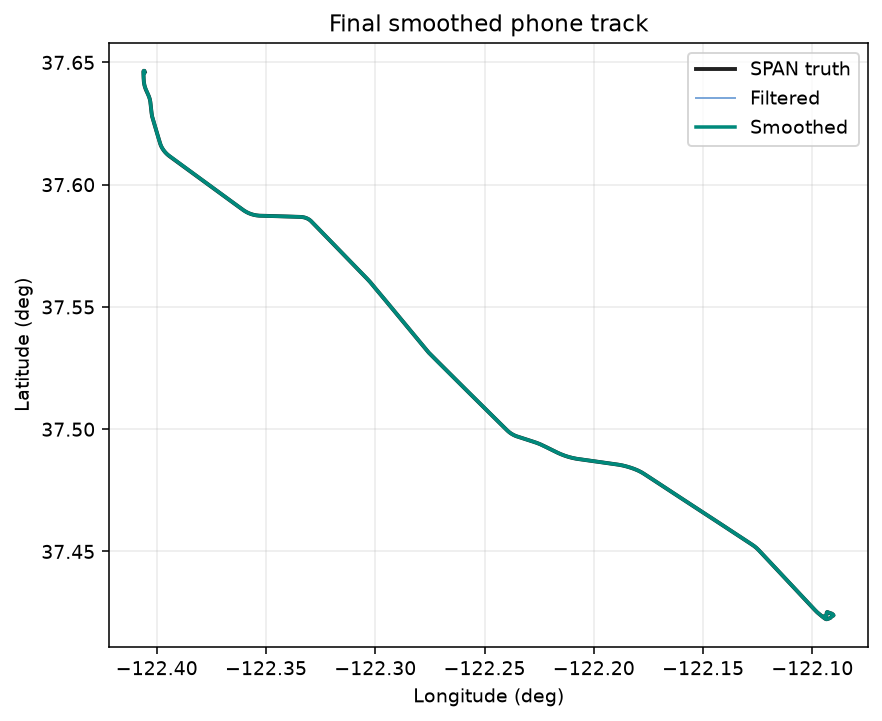

In [7]:
if READY:
    smoothed = sidereon.smooth_track_rts(history.finish())
    smoothed_xyz_m = np.asarray([epoch.state.position_m.copy() for epoch in smoothed.epochs])

    smoothed_llh = geodetic_from_ecef_m(smoothed_xyz_m)
    fig, ax = plt.subplots(figsize=(7.0, 5.6))
    ax.plot(truth_llh[:, 1], truth_llh[:, 0], color="#222222", lw=2.0, label="SPAN truth")
    ax.plot(filtered_llh[:, 1], filtered_llh[:, 0], color="#7aa6d9", lw=1.0, label="Filtered")
    ax.plot(smoothed_llh[:, 1], smoothed_llh[:, 0], color="#00897b", lw=1.8, label="Smoothed")
    ax.set_title("Final smoothed phone track")
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.legend(loc="best")
    plt.show()
else:
    print("Skipped smoothing because the input files are missing.")

## Numbers against independent truth

Every solved epoch is counted. The two sparse RINEX epochs without enough C1C satellites were skipped before any comparison.

In [8]:
def error_summary(name, positions_m, truth_m):
    error_m = np.linalg.norm(positions_m - truth_m, axis=1)
    return {
        "name": name,
        "rms_m": float(np.sqrt(np.mean(error_m**2))),
        "max_m": float(np.max(error_m)),
        "median_m": float(np.median(error_m)),
        "p95_m": float(np.percentile(error_m, 95)),
    }

if READY:
    summaries = [
        error_summary("Raw SPP", raw_xyz_m, truth_xyz_m),
        error_summary("Filtered", filtered_xyz_m, truth_xyz_m),
        error_summary("Smoothed", smoothed_xyz_m, truth_xyz_m),
    ]
    print(f"Epochs compared: {len(truth_xyz_m)}")
    print("Method       RMS m   Max m   Median m   P95 m")
    for row in summaries:
        print(
            f"{row['name']:<10} "
            f"{row['rms_m']:7.2f} "
            f"{row['max_m']:7.2f} "
            f"{row['median_m']:10.2f} "
            f"{row['p95_m']:7.2f}"
        )
else:
    print("Skipped error table because the input files are missing.")

Epochs compared: 1731
Method       RMS m   Max m   Median m   P95 m
Raw SPP       6.99   55.62       4.87   11.87
Filtered      5.64   21.25       4.44   10.20
Smoothed      4.76   12.97       4.17    7.40
